# USA–Israel vs Iran Conflict Outcome Prediction Using Machine Learning

# Side A = USA + Israel

# Side B = Iran

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Loading Data

In [2]:
# Loading data in pandas DataFrame
df = pd.read_csv(r"C:\Users\chara\Downloads\israel_usa_iran_conflict_dataset.csv")

In [3]:
# Printing first 5 rows 
df.head()

,scenario,side_A,side_B,gdp_A_trillion,gdp_B_trillion,defense_budget_A_billion,defense_budget_B_billion,active_personnel_A,active_personnel_B,reserve_personnel_A,...,technology_index_B,nuclear_A,nuclear_B,geography_advantage_A,geography_advantage_B,oil_dependency_A,oil_dependency_B,sanctions_index_A,sanctions_index_B,winner
0,1,USA+Israel,Iran,27.00,0.45,930,10,1500000,610000,800000,...,6,1,0,7,8,3,8,2,9,1
1,2,USA,Iran,26.80,0.45,900,10,1330000,610000,780000,...,6,1,0,6,8,3,8,2,9,1
2,3,Israel,Iran,0.52,0.45,35,10,170000,610000,465000,...,6,1,0,7,8,4,8,2,9,1
3,4,Iran,Israel,0.45,0.52,10,35,610000,170000,350000,...,9,0,1,8,7,8,4,9,2,0
4,5,USA+Israel,Iran,27.00,0.45,920,11,1480000,620000,790000,...,6,1,0,7,8,3,8,2,9,1


In [4]:
# Printing las 5 rows of dataset
df.tail()

,scenario,side_A,side_B,gdp_A_trillion,gdp_B_trillion,defense_budget_A_billion,defense_budget_B_billion,active_personnel_A,active_personnel_B,reserve_personnel_A,...,technology_index_B,nuclear_A,nuclear_B,geography_advantage_A,geography_advantage_B,oil_dependency_A,oil_dependency_B,sanctions_index_A,sanctions_index_B,winner
5,6,USA+Israel,Iran,27.00,0.45,915,12,1470000,630000,785000,...,6,1,0,7,8,3,8,2,9,1
6,7,USA,Iran,26.80,0.45,905,10,1320000,610000,770000,...,6,1,0,6,8,3,8,2,9,1
7,8,Israel,Iran,0.52,0.45,36,11,175000,620000,470000,...,6,1,0,7,8,4,8,2,9,1
8,9,USA+Israel,Iran,27.00,0.45,910,10,1460000,610000,780000,...,6,1,0,7,8,3,8,2,9,1
9,10,Iran,USA,0.45,27.00,10,900,610000,1330000,350000,...,10,0,1,8,6,8,3,9,2,0


In [5]:
# Shape of the dataset
df.shape

(10, 38)

In [6]:
# Information about dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   scenario                  10 non-null     int64  
 1   side_A                    10 non-null     object 
 2   side_B                    10 non-null     object 
 3   gdp_A_trillion            10 non-null     float64
 4   gdp_B_trillion            10 non-null     float64
 5   defense_budget_A_billion  10 non-null     int64  
 6   defense_budget_B_billion  10 non-null     int64  
 7   active_personnel_A        10 non-null     int64  
 8   active_personnel_B        10 non-null     int64  
 9   reserve_personnel_A       10 non-null     int64  
 10  reserve_personnel_B       10 non-null     int64  
 11  aircraft_A                10 non-null     int64  
 12  aircraft_B                10 non-null     int64  
 13  tanks_A                   10 non-null     int64  
 14  tanks_B      

In [7]:
# Checking for null values
df.isnull().sum()

scenario                    0
side_A                      0
side_B                      0
gdp_A_trillion              0
gdp_B_trillion              0
defense_budget_A_billion    0
defense_budget_B_billion    0
active_personnel_A          0
active_personnel_B          0
reserve_personnel_A         0
reserve_personnel_B         0
aircraft_A                  0
aircraft_B                  0
tanks_A                     0
tanks_B                     0
naval_assets_A              0
naval_assets_B              0
missile_index_A             0
missile_index_B             0
drone_index_A               0
drone_index_B               0
cyber_capability_A          0
cyber_capability_B          0
logistics_score_A           0
logistics_score_B           0
allies_A                    0
allies_B                    0
technology_index_A          0
technology_index_B          0
nuclear_A                   0
nuclear_B                   0
geography_advantage_A       0
geography_advantage_B       0
oil_depend

In [8]:
# Statistical measures 
df.describe()

,scenario,gdp_A_trillion,gdp_B_trillion,defense_budget_A_billion,defense_budget_B_billion,active_personnel_A,active_personnel_B,reserve_personnel_A,reserve_personnel_B,aircraft_A,...,technology_index_B,nuclear_A,nuclear_B,geography_advantage_A,geography_advantage_B,oil_dependency_A,oil_dependency_B,sanctions_index_A,sanctions_index_B,winner
count,10.00000,10.000000,10.000000,10.000000,10.000000,1.000000e+01,1.000000e+01,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,16.354000,3.112000,557.100000,101.900000,1.012500e+06,6.420000e+05,634000.000000,407500.000000,8196.000000,...,6.700000,0.800000,0.200000,7.000000,7.700000,4.200000,7.100000,3.400000,7.600000,0.800000
std,3.02765,13.658097,8.393416,460.044309,280.530232,5.574109e+05,2.793564e+05,197930.964396,135569.785228,6560.110433,...,1.494434,0.421637,0.421637,0.666667,0.674949,2.043961,1.911951,2.951459,2.951459,0.421637
min,1.00000,0.450000,0.450000,10.000000,10.000000,1.700000e+05,1.700000e+05,350000.000000,350000.000000,550.000000,...,6.000000,0.000000,0.000000,6.000000,6.000000,3.000000,3.000000,2.000000,2.000000,0.000000
25%,3.25000,0.520000,0.450000,35.250000,10.000000,6.100000e+05,6.100000e+05,466250.000000,350000.000000,602.500000,...,6.000000,1.000000,0.000000,7.000000,8.000000,3.000000,8.000000,2.000000,9.000000,1.000000
50%,5.50000,26.800000,0.450000,902.500000,10.500000,1.325000e+06,6.100000e+05,775000.000000,352500.000000,12950.000000,...,6.000000,1.000000,0.000000,7.000000,8.000000,3.000000,8.000000,2.000000,9.000000,1.000000
75%,7.75000,27.000000,0.450000,913.750000,11.750000,1.467500e+06,6.200000e+05,783750.000000,363750.000000,13375.000000,...,6.000000,1.000000,0.000000,7.000000,8.000000,4.000000,8.000000,2.000000,9.000000,1.000000
max,10.00000,27.000000,27.000000,930.000000,900.000000,1.500000e+06,1.330000e+06,800000.000000,780000.000000,13600.000000,...,10.000000,1.000000,1.000000,8.000000,8.000000,8.000000,8.000000,9.000000,9.000000,1.000000


## Data Preprocessing

In [9]:
df = df.drop(["scenario","side_A","side_B"], axis=1)

df.head()

,gdp_A_trillion,gdp_B_trillion,defense_budget_A_billion,defense_budget_B_billion,active_personnel_A,active_personnel_B,reserve_personnel_A,reserve_personnel_B,aircraft_A,aircraft_B,...,technology_index_B,nuclear_A,nuclear_B,geography_advantage_A,geography_advantage_B,oil_dependency_A,oil_dependency_B,sanctions_index_A,sanctions_index_B,winner
0,27.00,0.45,930,10,1500000,610000,800000,350000,13600,550,...,6,1,0,7,8,3,8,2,9,1
1,26.80,0.45,900,10,1330000,610000,780000,350000,13000,550,...,6,1,0,6,8,3,8,2,9,1
2,0.52,0.45,35,10,170000,610000,465000,350000,600,550,...,6,1,0,7,8,4,8,2,9,1
3,0.45,0.52,10,35,610000,170000,350000,465000,550,600,...,9,0,1,8,7,8,4,9,2,0
4,27.00,0.45,920,11,1480000,620000,790000,360000,13400,570,...,6,1,0,7,8,3,8,2,9,1


In [10]:
## Separating Features and Targets
X = df.drop("winner", axis=1)

Y = df["winner"]

In [11]:
print(X)

   gdp_A_trillion  gdp_B_trillion  defense_budget_A_billion  \
0           27.00            0.45                       930   
1           26.80            0.45                       900   
2            0.52            0.45                        35   
3            0.45            0.52                        10   
4           27.00            0.45                       920   
5           27.00            0.45                       915   
6           26.80            0.45                       905   
7            0.52            0.45                        36   
8           27.00            0.45                       910   
9            0.45           27.00                        10   

   defense_budget_B_billion  active_personnel_A  active_personnel_B  \
0                        10             1500000              610000   
1                        10             1330000              610000   
2                        10              170000              610000   
3                     

In [12]:
print(Y)

0    1
1    1
2    1
3    0
4    1
5    1
6    1
7    1
8    1
9    0
Name: winner, dtype: int64


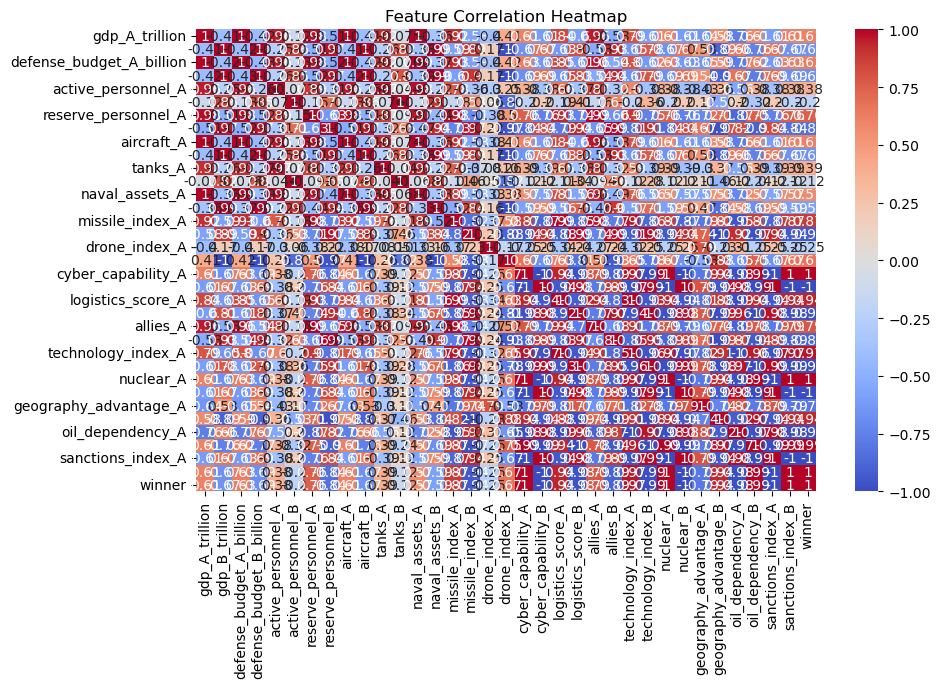

In [13]:
## Exploratory Data Analysis
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [14]:
corr_matrix = df.corr()

corr_matrix

,gdp_A_trillion,gdp_B_trillion,defense_budget_A_billion,defense_budget_B_billion,active_personnel_A,active_personnel_B,reserve_personnel_A,reserve_personnel_B,aircraft_A,aircraft_B,...,technology_index_B,nuclear_A,nuclear_B,geography_advantage_A,geography_advantage_B,oil_dependency_A,oil_dependency_B,sanctions_index_A,sanctions_index_B,winner
gdp_A_trillion,1.000000,-0.410339,0.999767,-0.421536,0.959363,-0.124990,0.979926,-0.508904,0.999669,-0.410232,...,-0.606031,0.613712,-0.613712,-0.643086,0.575075,-0.759038,0.609031,-0.613712,0.613712,0.613712
gdp_B_trillion,-0.410339,1.000000,-0.419077,0.999689,-0.254459,0.864026,-0.505628,0.966103,-0.410724,0.999997,...,0.777531,-0.668618,0.668618,0.528589,-0.886202,0.655145,-0.755188,0.668618,-0.668618,-0.668618
defense_budget_A_billion,0.999767,-0.419077,1.000000,-0.430509,0.955700,-0.127621,0.983396,-0.519812,0.999708,-0.418980,...,-0.618936,0.626781,-0.626781,-0.646677,0.587320,-0.769744,0.622000,-0.626781,0.626781,0.626781
defense_budget_B_billion,-0.421536,0.999689,-0.430509,1.000000,-0.261304,0.851329,-0.519412,0.972230,-0.421926,0.999708,...,0.792901,-0.686871,0.686871,0.543613,-0.897428,0.673031,-0.771227,0.686871,-0.686871,-0.686871
active_personnel_A,0.959363,-0.254459,0.955700,-0.261304,1.000000,-0.076528,0.891073,-0.311731,0.961202,-0.254105,...,-0.375811,0.380574,-0.380574,-0.427572,0.356614,-0.556372,0.377671,-0.380574,0.380574,0.380574
active_personnel_B,-0.124990,0.864026,-0.127621,0.851329,-0.076528,1.000000,-0.153886,0.707201,-0.125057,0.863739,...,0.355573,-0.203758,0.203758,0.167051,-0.532717,0.199652,-0.322860,0.203758,-0.203758,-0.203758
reserve_personnel_A,0.979926,-0.505628,0.983396,-0.519412,0.891073,-0.153886,1.000000,-0.628465,0.980534,-0.505664,...,-0.746764,0.756229,-0.756229,-0.715738,0.708619,-0.871447,0.750461,-0.756229,0.756229,0.756229
reserve_personnel_B,-0.508904,0.966103,-0.519812,0.972230,-0.311731,0.707201,-0.628465,1.000000,-0.509284,0.966363,...,0.911758,-0.835842,0.835842,0.670012,-0.974471,0.817998,-0.896981,0.835842,-0.835842,-0.835842
aircraft_A,0.999669,-0.410724,0.999708,-0.421926,0.961202,-0.125057,0.980534,-0.509284,1.000000,-0.410624,...,-0.606599,0.614288,-0.614288,-0.630071,0.575614,-0.759396,0.609602,-0.614288,0.614288,0.614288
aircraft_B,-0.410232,0.999997,-0.418980,0.999708,-0.254105,0.863739,-0.505664,0.966363,-0.410624,1.000000,...,0.777953,-0.669118,0.669118,0.529302,-0.886512,0.655532,-0.755628,0.669118,-0.669118,-0.669118


In [15]:
corr_matrix["winner"].sort_values(ascending=False)

sanctions_index_B           1.000000
winner                      1.000000
cyber_capability_A          1.000000
nuclear_A                   1.000000
oil_dependency_B            0.992372
technology_index_A          0.968246
logistics_score_A           0.943242
geography_advantage_B       0.937043
missile_index_A             0.875000
allies_A                    0.785552
reserve_personnel_A         0.756229
drone_index_B               0.666667
defense_budget_A_billion    0.626781
aircraft_A                  0.614288
gdp_A_trillion              0.613712
naval_assets_A              0.570117
tanks_A                     0.389887
active_personnel_A          0.380574
tanks_B                    -0.121727
active_personnel_B         -0.203758
drone_index_A              -0.250000
naval_assets_B             -0.592360
gdp_B_trillion             -0.668618
aircraft_B                 -0.669118
defense_budget_B_billion   -0.686871
geography_advantage_A      -0.790569
reserve_personnel_B        -0.835842
a

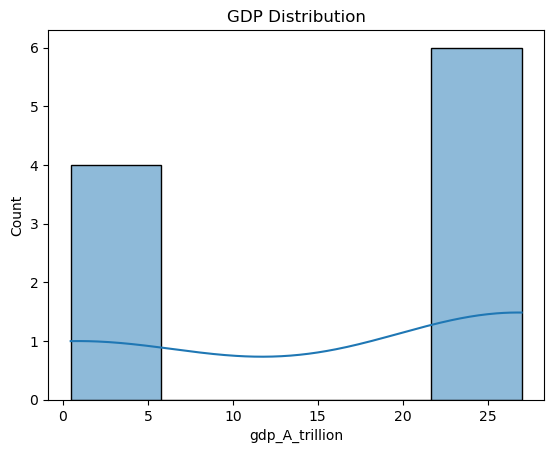

In [16]:
sns.histplot(df["gdp_A_trillion"], kde=True)

plt.title("GDP Distribution")

plt.show()

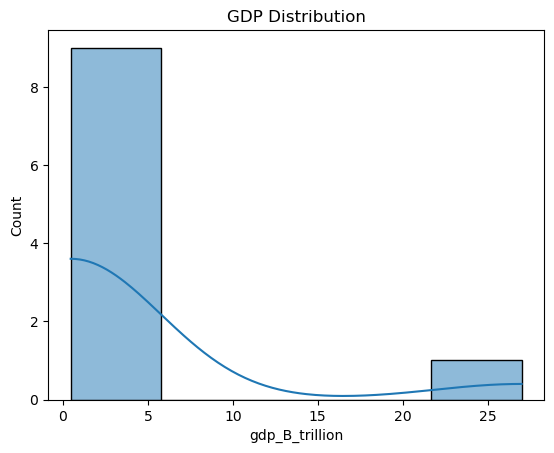

In [17]:
sns.histplot(df["gdp_B_trillion"], kde=True)

plt.title("GDP Distribution")

plt.show()

## Feature Scaling

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Train Test Split

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size = 0.2, random_state = 26)

In [20]:
print(X.shape, X_train.shape, X_test.shape)

(10, 34) (8, 34) (2, 34)


In [21]:
print(Y.shape, Y_train.shape, Y_test.shape)

(10,) (8,) (2,)


## Model Selection

In [22]:
models = {

    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()

}

## Model Training

In [23]:
for name, model in models.items():

    print("==============")
    print("Model:", name)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print("Accuracy:", accuracy)

    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, Y_pred))

    print("Classification Report:")
    print(classification_report(Y_test, Y_pred))

Model: Logistic Regression
Accuracy: 1.0
Confusion Matrix:
[[2]]
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Model: Random Forest
Accuracy: 1.0
Confusion Matrix:
[[2]]
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



C:\Users\chara\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\chara\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Here, two model performs very well having accuracy is 100

## Train Final Model 

In [24]:
model = RandomForestClassifier()

model.fit(X_train, Y_train)

RandomForestClassifier()

## Prediction System

In [25]:
new_data = pd.DataFrame({

'gdp_A_trillion':[27],
'gdp_B_trillion':[0.45],
'defense_budget_A_billion':[930],
'defense_budget_B_billion':[10],
'active_personnel_A':[1500000],
'active_personnel_B':[610000],
'reserve_personnel_A':[800000],
'reserve_personnel_B':[350000],
'aircraft_A':[13600],
'aircraft_B':[550],
'tanks_A':[6000],
'tanks_B':[2895],
'naval_assets_A':[540],
'naval_assets_B':[101],
'missile_index_A':[9],
'missile_index_B':[7],
'drone_index_A':[8],
'drone_index_B':[8],
'cyber_capability_A':[9],
'cyber_capability_B':[7],
'logistics_score_A':[10],
'logistics_score_B':[7],
'allies_A':[35],
'allies_B':[6],
'technology_index_A':[10],
'technology_index_B':[6],
'nuclear_A':[1],
'nuclear_B':[0],
'geography_advantage_A':[7],
'geography_advantage_B':[8],
'oil_dependency_A':[3],
'oil_dependency_B':[8],
'sanctions_index_A':[2],
'sanctions_index_B':[9]

})

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

if prediction[0] == 1:
    
    print("Prediction: Side A is likely to win")

else:
    
    print("Prediction: Side B is likely to win")

Prediction: Side A is likely to win


C:\Users\chara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Feature Importance 

In [26]:
importances = model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importances

})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
8,aircraft_A,0.089888
24,technology_index_A,0.067416
15,missile_index_B,0.056180
9,aircraft_B,0.056180
5,active_personnel_B,0.044944
1,gdp_B_trillion,0.044944
33,sanctions_index_B,0.044944
3,defense_budget_B_billion,0.044944
2,defense_budget_A_billion,0.044944
30,oil_dependency_A,0.033708


## Feature Importance Visualization

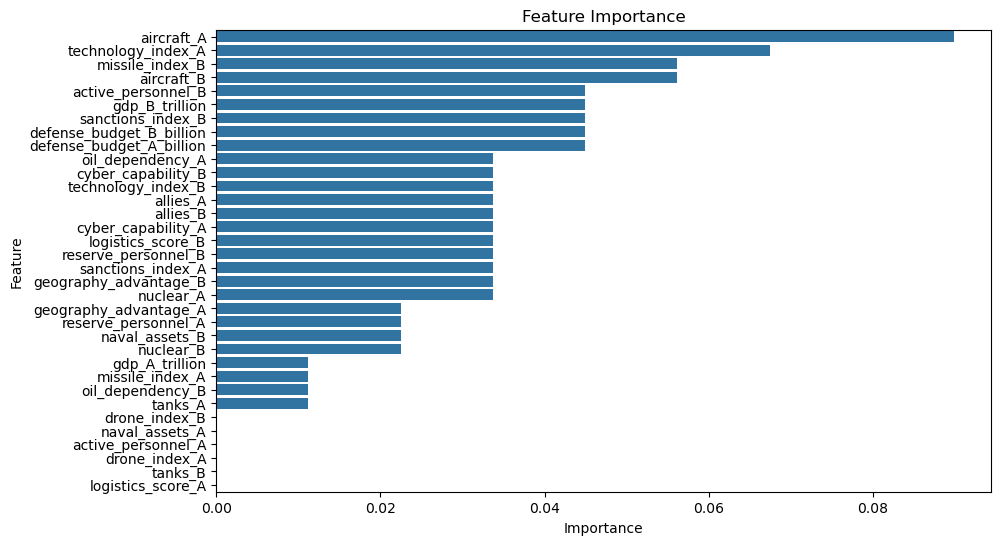

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    
    x="Importance",
    y="Feature",
    data=feature_importance_df

)

plt.title("Feature Importance")

plt.show()

## Prediction - 2

In [28]:
new_data = pd.DataFrame({

'gdp_A_trillion':[27],
'gdp_B_trillion':[0.45],

'defense_budget_A_billion':[950],
'defense_budget_B_billion':[10],

'active_personnel_A':[1500000],
'active_personnel_B':[600000],

'reserve_personnel_A':[800000],
'reserve_personnel_B':[350000],

'aircraft_A':[14000],
'aircraft_B':[550],

'tanks_A':[6500],
'tanks_B':[2895],

'naval_assets_A':[600],
'naval_assets_B':[101],

'missile_index_A':[9],
'missile_index_B':[6],

'drone_index_A':[9],
'drone_index_B':[7],

'cyber_capability_A':[9],
'cyber_capability_B':[6],

'logistics_score_A':[10],
'logistics_score_B':[7],

'allies_A':[35],
'allies_B':[6],

'technology_index_A':[10],
'technology_index_B':[6],

'nuclear_A':[1],
'nuclear_B':[0],

'geography_advantage_A':[7],
'geography_advantage_B':[8],

'oil_dependency_A':[3],
'oil_dependency_B':[8],

'sanctions_index_A':[2],
'sanctions_index_B':[9]

})


new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

if prediction[0] == 1:
    
    print("Prediction: Side A is likely to win")

else:
    
    print("Prediction: Side B is likely to win")

prob = model.predict_proba(new_data_scaled)

print("Side A win probability:", prob[0][1])
print("Side B win probability:", prob[0][0])

Prediction: Side A is likely to win
Side A win probability: 0.59
Side B win probability: 0.41


C:\Users\chara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\chara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Here, The prediction says Side A wins which is USA + Israel 